In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch import nn
from torch import optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import CIFAR100, CIFAR10
from torchvision.transforms import transforms

from einops import rearrange, repeat

In [2]:
!ls

cifar-10-batches-py  cifar-10-python.tar.gz  sample_data


# Hyper-parameters

In [3]:
BATCH_SIZE = 32
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
EPOCHS = 10

IMAGE_SIZE = (224, 224)
CHANNELS = 3
PATCH_SIZE = (16, 16)
DIM = 768
NUM_HEAD = 16
HEAD_DIM = 48
MLP_DIM = 3072
NUM_ENC_BLK = 12
NUM_CLASS = 10
DROPOUT = 0.0

In [35]:
MEAN = (0.49139968 , 0.48215827, 0.44653124)
STD = (0.24703233,0.24348505, 0.26158768)

# Dataset Load & Prep

In [4]:
train_dataset = CIFAR10("./", train=True, download=True)
test_dataset = CIFAR10("./", train=False, download=True)

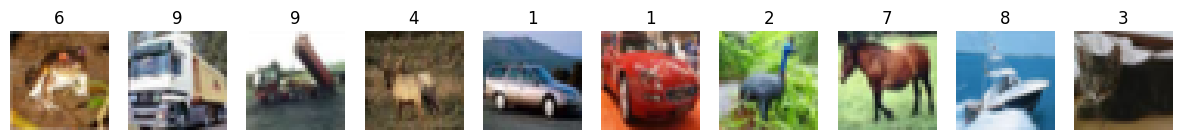

In [5]:
plt.figure(figsize=(15, 25))
for i in range(10):
    img, label = train_dataset[i]
    plt.subplot(1, 10, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")
plt.show()

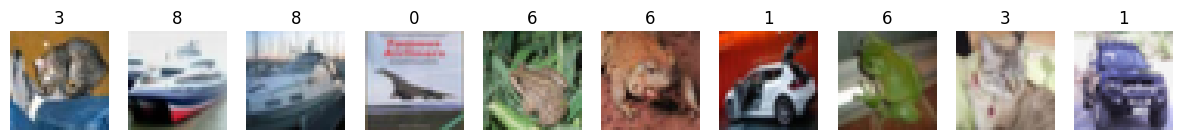

In [6]:
plt.figure(figsize=(15, 25))
for i in range(10):
    img, label = test_dataset[i]
    plt.subplot(1, 10, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")
plt.show()

In [7]:
img, label = train_dataset[0]
print(img.size)

(32, 32)


In [8]:
a = np.array(img)
a.shape

(32, 32, 3)

### Calculate Mean & Std

In [9]:
def calculate_dataset_mean(dataset):
    imgs = np.stack([img for img, _ in dataset])
    imgs = imgs.astype(np.float32) / 255.0
    return imgs[:, :, :, 0].mean(), imgs[:, :, :, 1].mean(), imgs[:, :, :, 2].mean()

def calculate_dataset_std(dataset):
    imgs = np.stack([img for img, _ in dataset])
    imgs = imgs.astype(np.float32) / 255.0
    return imgs[:, :, :, 0].std(), imgs[:, :, :, 1].std(), imgs[:, :, :, 2].std()

In [10]:
mean = calculate_dataset_mean(train_dataset)
std = calculate_dataset_std(train_dataset)
print("mean: ", *np.array(mean))
print("std: ", *np.array(std))

mean:  0.49139968 0.48215827 0.44653124
std:  0.24703233 0.24348505 0.26158768


## TODO: Augmentation

In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(IMAGE_SIZE),
    # transforms.Normalize((0.5070746, 0.48654896, 0.44091788), (0.26733422,0.25643846, 0.27615058)) # CIFAR100
    transforms.Normalize((0.49139968 , 0.48215827, 0.44653124), (0.24703233,0.24348505, 0.26158768)) # CIFAR10

])

In [12]:
train_dataset = CIFAR10("./", train=True, transform=transform, download=True)
test_dataset = CIFAR10("./", train=False, transform=transform, download=True)

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 50000
Test: 10000


In [13]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 1563
Test batches: 313


# Modeling


In [14]:
class PatchEmbedding(nn.Module):
    def __init__(self, patch_size, patch_dim, dim):
        super().__init__()

        self.patch_height, self.patch_width = patch_size
        self.layernorm = nn.LayerNorm(patch_dim, eps=1e-6, elementwise_affine=True)
        self.linear = nn.Linear(patch_dim, dim)

    def forward(self, x):
        B, C, H, W = x.shape
        x = rearrange(x, 'b c (h ph) (w pw) -> b (h w) (c ph pw)', ph=self.patch_height, pw=self.patch_width)
        x = self.layernorm(x)
        x = self.linear(x)
        return x


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, num_head, head_dim, dropout):
        super().__init__()

        total_dim = num_head * head_dim
        self.scale = head_dim ** -0.5
        self.num_head = num_head

        self.to_q = nn.Linear(dim, total_dim, bias=False)
        self.to_k = nn.Linear(dim, total_dim, bias=False)
        self.to_v = nn.Linear(dim, total_dim, bias=False)

        self.to_out = nn.Linear(total_dim, dim)
        self.softmax = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape
        q = self.to_q(x).reshape(B, N, self.num_head, -1).permute(0, 2, 1, 3)
        k = self.to_k(x).reshape(B, N, self.num_head, -1).permute(0, 2, 1, 3)
        v = self.to_v(x).reshape(B, N, self.num_head, -1).permute(0, 2, 1, 3)

        attn = torch.matmul(q, k.transpose(-1, -2)) * self.scale
        attn = self.softmax(attn)
        out = torch.matmul(attn, v)

        out = out.permute(0, 2, 1, 3).reshape(B, N, -1)
        out = self.dropout(out)
        out = self.to_out(out)

        return out


class FeedForward(nn.Module):
    def __init__(self, dim, mlp_dim, dropout):
        super().__init__()

        self.linear1 = nn.Linear(dim, mlp_dim)
        self.linear2 = nn.Linear(mlp_dim, dim)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.linear1(x)
        x = self.dropout(x)
        x = self.activation(x)
        x = self.linear2(x)
        return x


class EncoderBlock(nn.Module):
    def __init__(self, dim, num_head, head_dim, mlp_dim, dropout):
        super().__init__()

        self.layernorm1 = nn.LayerNorm(dim, eps=1e-6, elementwise_affine=True)
        self.layernorm2 = nn.LayerNorm(dim, eps=1e-6, elementwise_affine=True)
        self.attention = MultiHeadSelfAttention(dim, num_head, head_dim, dropout)
        self.ffn = FeedForward(dim, mlp_dim, dropout)

    def forward(self, x):
        residual = x
        x = self.layernorm1(x)
        x = self.attention(x) + residual

        residual = x
        x = self.layernorm2(x)
        x = self.ffn(x) + residual

        return x

class Encoder(nn.Module):
    def __init__(self, num_enc_blk, dim, num_head, head_dim, mlp_dim, dropout):
        super().__init__()
        self.encoderBlocks = nn.ModuleList([EncoderBlock(dim, num_head, head_dim, mlp_dim, dropout) for _ in range(num_enc_blk)])

    def forward(self, x):
        for blk in self.encoderBlocks:
            x = blk(x)
        return x


class VisionTransformer(nn.Module):
    def __init__(self, image_size, channels, patch_size, dim, num_head, head_dim, mlp_dim, num_enc_blk, num_class, dropout=0.1):
        super().__init__()

        image_height, image_width = image_size
        patch_height, patch_width = patch_size
        assert image_height % patch_height == 0 and image_width % patch_width == 0, 'Image dimension is must divided by patch dimension'

        num_patch = (image_height // patch_height) * (image_width // patch_width)
        patch_dim = patch_width * patch_height * channels

        self.patch_embedding = PatchEmbedding(patch_size, patch_dim, dim)
        self.positional_embedding = nn.Parameter(torch.randn((1, num_patch+1, dim)))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))

        self.dropout = nn.Dropout(dropout)
        self.encoder = Encoder(num_enc_blk, dim, num_head, head_dim, mlp_dim, dropout)

        self.mlpHead = nn.Linear(dim, num_class)

    def forward(self, x):
        B, C, H, W = x.shape

        cls_token = self.cls_token.expand(B, -1, -1)
        x = self.patch_embedding(x)
        x = torch.cat([cls_token, x], dim=1) + self.positional_embedding

        x = self.dropout(x)
        x = self.encoder(x)

        x = x[:, 0, :].squeeze() # extract cls token
        x = self.mlpHead(x)

        return x

In [15]:
def init_weight(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight.data)
        if module.bias is not None:
            nn.init.constant_(module.bias.data, 0)
    elif isinstance(module, nn.LayerNorm):
        nn.init.constant_(module.weight.data, 1)
        nn.init.constant_(module.bias.data, 0)

In [16]:
a = torch.randn(4, 2, 1, 1)
b = torch.randn(2, 1, 1)
c = a + b
c.shape

torch.Size([4, 2, 1, 1])

In [17]:
imgs, labels = next(iter(train_loader))
imgs.shape

torch.Size([32, 3, 224, 224])

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = VisionTransformer(IMAGE_SIZE, CHANNELS, PATCH_SIZE, DIM, NUM_HEAD, HEAD_DIM, MLP_DIM, NUM_ENC_BLK, NUM_CLASS, DROPOUT).to(device)
model.apply(init_weight)
print("device:", device)
print(model)

device: cuda
VisionTransformer(
  (patch_embedding): PatchEmbedding(
    (layernorm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
    (linear): Linear(in_features=768, out_features=768, bias=True)
  )
  (dropout): Dropout(p=0.0, inplace=False)
  (encoder): Encoder(
    (encoderBlocks): ModuleList(
      (0-11): 12 x EncoderBlock(
        (layernorm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (layernorm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attention): MultiHeadSelfAttention(
          (to_q): Linear(in_features=768, out_features=768, bias=False)
          (to_k): Linear(in_features=768, out_features=768, bias=False)
          (to_v): Linear(in_features=768, out_features=768, bias=False)
          (to_out): Linear(in_features=768, out_features=768, bias=True)
          (softmax): Softmax(dim=-1)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (ffn): FeedForward(
          (linear1): Linear(in_features=768, o

In [19]:
test_result = model(imgs.to(device))
test_result.shape

torch.Size([32, 10])

In [20]:
test_result

tensor([[ 7.6935e+00, -7.9029e+00,  6.7195e+00,  1.9558e+01,  1.7433e+00,
         -9.4125e+00, -1.0974e+01,  1.2065e+01, -4.3784e+00, -3.9917e+00],
        [-5.3906e+00, -7.4100e+00,  1.3000e+01,  1.3654e+01, -3.5820e+00,
         -6.1240e+00,  1.2570e+00,  1.7379e+01, -1.1414e+01, -1.2606e+01],
        [ 1.2802e+01, -6.2417e+00, -2.9111e-01,  1.3375e+01,  1.6220e-02,
         -5.0963e-01,  1.0929e+01,  9.8807e+00, -4.2254e+00, -3.3693e+00],
        [ 4.4032e+00, -6.2352e+00, -9.3611e+00, -1.1833e+01, -1.3589e+00,
          1.0998e+00,  2.8111e+01,  1.3029e+01,  1.4440e+01, -1.3347e+01],
        [ 2.3308e+00, -7.9053e+00,  1.7816e+01,  1.3889e+01, -6.9890e+00,
         -5.7234e+00, -3.1506e+00,  1.4767e+01, -6.4239e+00, -1.4404e+01],
        [ 3.6696e+00, -1.5494e+00,  4.4905e+00,  2.2212e+01,  2.8706e+00,
         -1.0383e+01, -2.1483e+01,  4.9761e-01, -9.5743e-01,  4.7441e-04],
        [-2.3249e-01, -7.8618e+00, -1.4813e+01, -1.8515e+01, -6.8910e+00,
          7.8755e-01,  2.8070e+0

In [21]:
test_result.argmax(dim=-1)

tensor([3, 7, 3, 6, 2, 3, 6, 3, 6, 6, 6, 3, 6, 3, 3, 7, 3, 3, 3, 6, 3, 3, 3, 3,
        3, 7, 0, 0, 2, 6, 6, 6], device='cuda:0')

# Train

In [22]:
def validate(model, dataloader, loss_func):
    model.eval()
    total_acc = 0
    total_loss = 0

    with torch.no_grad():
        with tqdm(dataloader, desc="Eval...") as pbar:
            for imgs, labels in pbar:
                imgs, labels = imgs.to(device), labels.to(device)
                pred = model(imgs)

                loss = loss_func(pred, labels)
                acc = torch.eq(labels, pred.argmax(dim=-1)).sum().item() / labels.shape[0]

                pbar.set_postfix(loss=loss.item(), acc=acc)

                total_loss += loss.item()
                total_acc += acc

    return total_loss / len(dataloader), total_acc / len(dataloader)

def train_one_epoch(model, dataloader, loss_func, optimizer):
    model.train()
    total_acc = 0
    total_loss = 0

    with tqdm(dataloader, desc="Training...") as pbar:
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            pred = model(imgs)

            acc = torch.eq(labels, pred.argmax(dim=-1)).sum().item() / labels.shape[0]
            loss = loss_func(pred, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            pbar.set_postfix(loss=loss.item(), acc=acc)

            total_acc += acc
            total_loss += loss.item()

    return total_loss / len(dataloader), total_acc / len(dataloader)

def train(model, train_loader, val_loader, loss_func, optimizer, epochs):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for e in range(epochs):
        print("Epoch {}".format(e+1))

        train_loss, train_acc = train_one_epoch(model, train_loader, loss_func, optimizer)
        val_loss, val_acc = validate(model, val_loader, loss_func)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        for key in history:
            print(f"{key}: {history[key][-1]}")

    return history

In [23]:
model = VisionTransformer(IMAGE_SIZE, CHANNELS, PATCH_SIZE, DIM, NUM_HEAD, HEAD_DIM, MLP_DIM, NUM_ENC_BLK, NUM_CLASS, DROPOUT).to(device)
model.apply(init_weight)
print(device)
print(model)

cuda
VisionTransformer(
  (patch_embedding): PatchEmbedding(
    (layernorm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
    (linear): Linear(in_features=768, out_features=768, bias=True)
  )
  (dropout): Dropout(p=0.0, inplace=False)
  (encoder): Encoder(
    (encoderBlocks): ModuleList(
      (0-11): 12 x EncoderBlock(
        (layernorm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (layernorm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attention): MultiHeadSelfAttention(
          (to_q): Linear(in_features=768, out_features=768, bias=False)
          (to_k): Linear(in_features=768, out_features=768, bias=False)
          (to_v): Linear(in_features=768, out_features=768, bias=False)
          (to_out): Linear(in_features=768, out_features=768, bias=True)
          (softmax): Softmax(dim=-1)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (ffn): FeedForward(
          (linear1): Linear(in_features=768, out_featu

In [24]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_func = nn.CrossEntropyLoss()

In [25]:
history = train(model, train_loader, test_loader, loss_func, optimizer, EPOCHS)

Epoch 1


Eval...: 100%|██████████| 313/313 [01:04<00:00,  4.88it/s, acc=0.375, loss=1.98]


train_loss: 2.66790078850183
train_acc: 0.35580614203454897
val_loss: 2.460468654815381
val_acc: 0.35173722044728434
Epoch 2


Eval...: 100%|██████████| 313/313 [01:04<00:00,  4.85it/s, acc=0.25, loss=2.42]


train_loss: 1.772479528047607
train_acc: 0.46009277031349965
val_loss: 1.8225633157327914
val_acc: 0.4187300319488818
Epoch 3


...

train_loss: 0.9789393161896018
train_acc: 0.6600887715930902
val_loss: 1.3066136044816088
val_acc: 0.5710862619808307
Epoch 9


Eval...: 100%|██████████| 313/313 [01:04<00:00,  4.86it/s, acc=0.688, loss=0.796]


train_loss: 0.8936312859133124
train_acc: 0.6855606206014075
val_loss: 1.1537378030463148
val_acc: 0.6117212460063898
Epoch 10


Eval...: 100%|██████████| 313/313 [01:04<00:00,  4.86it/s, acc=0.75, loss=1.03]

train_loss: 0.8166514528880726
train_acc: 0.708953134996801
val_loss: 1.146193915757889
val_acc: 0.6142172523961661


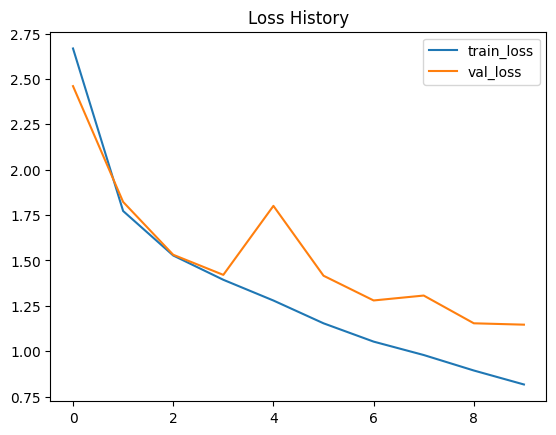

In [26]:
plt.title("Loss History")
plt.plot(range(EPOCHS), history["train_loss"], label="train_loss")
plt.plot(range(EPOCHS), history["val_loss"], label="val_loss")
plt.legend()
plt.show()

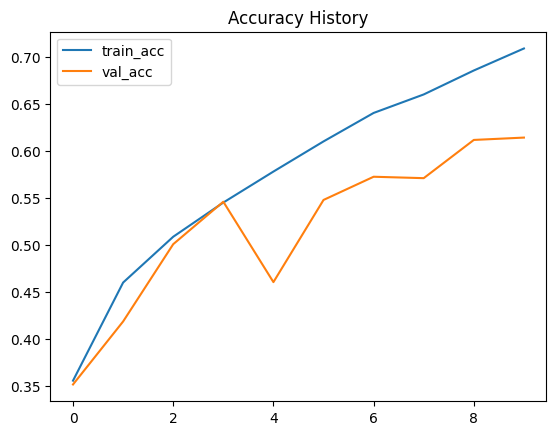

In [27]:
plt.title("Accuracy History")
plt.plot(range(EPOCHS), history["train_acc"], label="train_acc")
plt.plot(range(EPOCHS), history["val_acc"], label="val_acc")
plt.legend()
plt.show()

# Inference

In [28]:
loss, acc = validate(model, test_loader, loss_func)
print("Loss: {}\nAcc:{}".format(loss, acc))

Eval...: 100%|██████████| 313/313 [01:02<00:00,  4.99it/s, acc=0.562, loss=1.08]

Loss: 1.1462704028946142
Acc:0.613917731629393


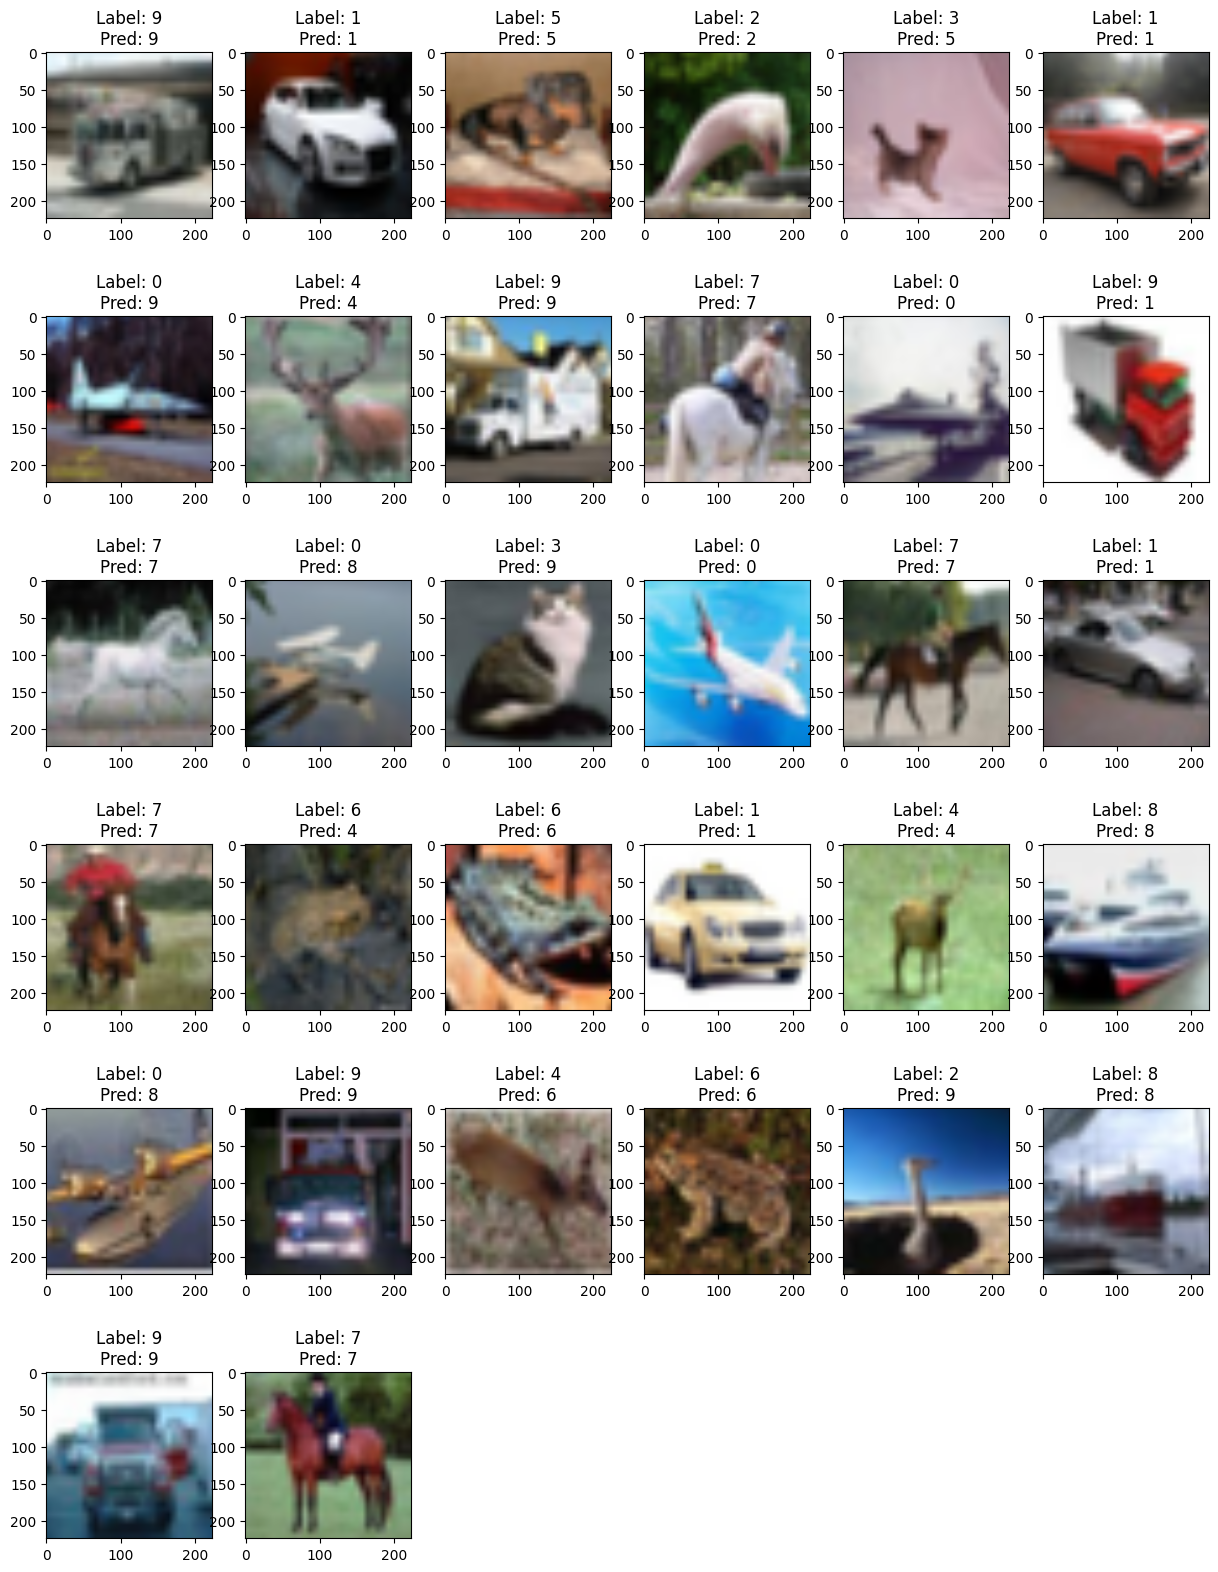

In [36]:
import math

plt.figure(figsize=(15, 20))
imgs, labels = next(iter(test_loader))
pred = model(imgs.to(device))

mean = torch.tensor(MEAN).reshape(3, 1, 1)
std = torch.tensor(STD).reshape(3, 1, 1)

plot_length = int(math.sqrt(len(labels))) + 1
for i, (img, p, label) in enumerate(zip(imgs, pred, labels)):
    plt.subplot(plot_length, plot_length, i+1)
    plt.title("Label: {}\nPred: {}".format(label.item(), p.argmax(-1).item()))

    converted_img = img * std + mean
    plt.imshow(converted_img.permute(1, 2, 0).detach().cpu().numpy())
plt.show()